# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [2]:
# Load Dataset
df = pd.read_excel("fake_social_media_global_2.0_with_missing.xlsx")

In [3]:
# Display first five records
df.head()

,platform,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,...,generic_comment_rate,suspicious_links_in_bio,verified,is_fake,username,username_length,digits_count,digit_ratio,special_char_count,repeat_char_count
0,X,1.0,180.0,1.0,431.0,679.0,0.633824,NaN,NaN,0.205945,...,5.0,1.0,0.0,0,dmitri,6,0,0.000000,0,0
1,NaN,1.0,214.0,NaN,426.0,729.0,0.583562,3164.0,202.0,0.063823,...,141.0,NaN,1.0,1,smpni6240,9,4,0.444444,0,0
2,X,1.0,87.0,NaN,426.0,721.0,0.590028,903.0,225.0,0.248894,...,62.0,1.0,0.0,1,qgph5q343j,10,4,0.400000,0,0
3,X,0.0,72.0,0.0,385.0,NaN,0.566176,3433.0,175.0,0.050961,...,117.0,1.0,1.0,0,mia,3,0,0.000000,0,0
4,Instagram,0.0,162.0,NaN,392.0,709.0,0.552113,NaN,207.0,0.162992,...,64.0,NaN,1.0,0,martin,6,0,0.000000,0,0


In [4]:
# Display last five records
df.tail()

,platform,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,...,generic_comment_rate,suspicious_links_in_bio,verified,is_fake,username,username_length,digits_count,digit_ratio,special_char_count,repeat_char_count
2995,X,0.0,118.0,0.0,399.0,683.0,0.583333,4401.0,216.0,0.049069,...,129.0,1.0,0.0,1,acc_h8xkpet0,12,2,0.166667,1,1
2996,Instagram,0.0,237.0,1.0,426.0,703.0,0.605114,2227.0,192.0,0.086176,...,120.0,NaN,0.0,0,ananya.6004,11,4,0.363636,1,1
2997,Instagram,1.0,33.0,1.0,418.0,718.0,0.581363,3737.0,203.0,0.054307,...,58.0,0.0,1.0,0,yusuf.1282,10,4,0.400000,1,0
2998,Facebook,1.0,168.0,0.0,NaN,722.0,0.561549,932.0,202.0,0.216506,...,30.0,1.0,1.0,0,kojo,4,0,0.000000,0,0
2999,Facebook,NaN,9.0,0.0,382.0,708.0,0.538787,1543.0,197.0,NaN,...,139.0,0.0,1.0,1,hbxfr27wz4,10,3,0.300000,0,0


In [5]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (3000, 24)


In [6]:
# Display all column names
print(df.columns)

Index(['platform', 'has_profile_pic', 'bio_length', 'username_randomness',
       'followers', 'following', 'follower_following_ratio',
       'account_age_days', 'posts', 'posts_per_day',
       'caption_similarity_score', 'content_similarity_score',
       'follow_unfollow_rate', 'spam_comments_rate', 'generic_comment_rate',
       'suspicious_links_in_bio', 'verified', 'is_fake', 'username',
       'username_length', 'digits_count', 'digit_ratio', 'special_char_count',
       'repeat_char_count'],
      dtype='object')


In [7]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   platform                  2667 non-null   object 
 1   has_profile_pic           2655 non-null   float64
 2   bio_length                2671 non-null   float64
 3   username_randomness       2663 non-null   float64
 4   followers                 2662 non-null   float64
 5   following                 2667 non-null   float64
 6   follower_following_ratio  2644 non-null   float64
 7   account_age_days          2657 non-null   float64
 8   posts                     2683 non-null   float64
 9   posts_per_day             2689 non-null   float64
 10  caption_similarity_score  2670 non-null   float64
 11  content_similarity_score  2672 non-null   float64
 12  follow_unfollow_rate      2692 non-null   float64
 13  spam_comments_rate        2662 non-null   float64
 14  generic_

In [8]:
# Summary statistics
df.describe()

,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,...,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake,username_length,digits_count,digit_ratio,special_char_count,repeat_char_count
count,2655.000000,2671.000000,2663.000000,2662.000000,2667.000000,2644.000000,2657.000000,2683.000000,2689.000000,2670.000000,...,2662.000000,2633.000000,2640.000000,2663.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.492655,124.181206,0.503192,399.984222,700.841395,0.570651,2490.854347,200.295937,0.273948,0.503490,...,99.440270,74.568173,0.503409,0.494931,0.353000,9.057333,3.051333,0.314868,0.540000,0.335000
std,0.500040,71.199830,0.500084,20.082031,25.841196,0.035102,1436.750871,14.233918,1.693301,0.286027,...,57.970155,43.672848,0.500083,0.500068,0.477982,2.215479,1.777381,0.183668,0.498481,0.544861
min,0.000000,0.000000,0.000000,334.000000,616.000000,0.467377,2.000000,151.000000,0.034999,0.000146,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,65.000000,0.000000,387.000000,684.000000,0.545967,1247.000000,190.000000,0.053500,0.259749,...,49.000000,36.000000,0.000000,0.000000,0.000000,8.000000,2.000000,0.166667,0.000000,0.000000
50%,0.000000,124.000000,1.000000,400.000000,701.000000,0.570800,2455.000000,200.000000,0.080808,0.510672,...,100.000000,76.000000,1.000000,0.000000,0.000000,9.000000,4.000000,0.400000,1.000000,0.000000
75%,1.000000,184.500000,1.000000,413.000000,718.000000,0.593853,3746.000000,209.000000,0.160743,0.748773,...,149.000000,111.000000,1.000000,1.000000,1.000000,10.000000,4.000000,0.444444,1.000000,1.000000
max,1.000000,249.000000,1.000000,472.000000,789.000000,0.693679,4997.000000,254.000000,73.333333,0.999496,...,199.000000,149.000000,1.000000,1.000000,1.000000,14.000000,8.000000,0.800000,1.000000,3.000000


# Exploratory Data Analysis (EDA) 

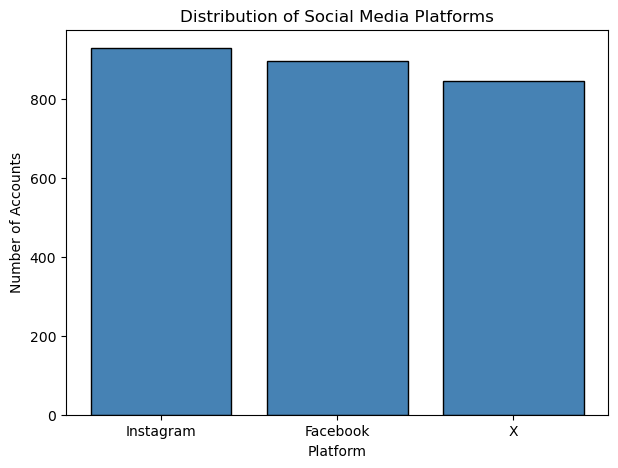

In [9]:
platform_counts = df['platform'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(platform_counts.index, platform_counts.values,
        color='steelblue', edgecolor='black')

plt.title("Distribution of Social Media Platforms")
plt.xlabel("Platform")
plt.ylabel("Number of Accounts")

plt.show()

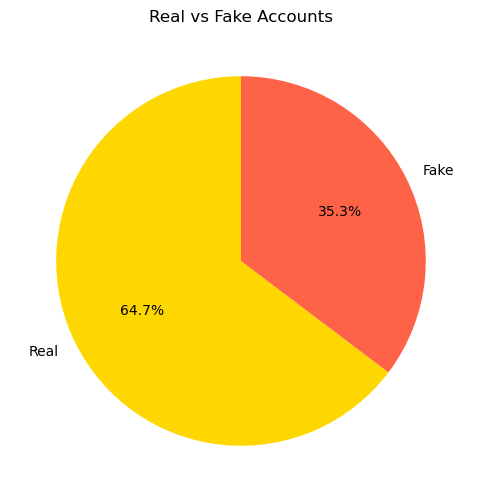

In [10]:
labels = ['Real', 'Fake']
sizes = df['is_fake'].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        colors=['gold','tomato'],
        startangle=90)

plt.title("Real vs Fake Accounts")
plt.show()

<Figure size 700x500 with 0 Axes>

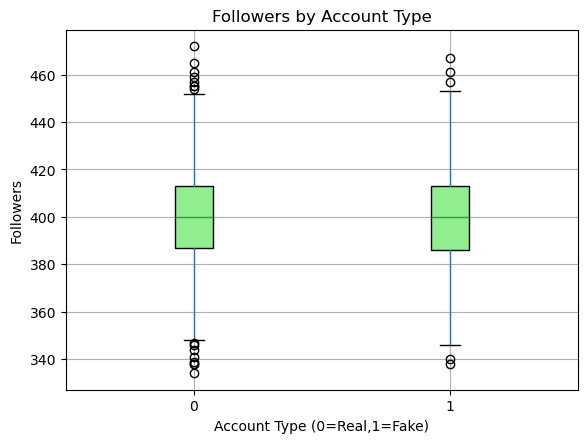

In [11]:
plt.figure(figsize=(7,5))

df.boxplot(column='followers',
           by='is_fake',
           patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))

plt.title("Followers by Account Type")
plt.suptitle("")
plt.xlabel("Account Type (0=Real,1=Fake)")
plt.ylabel("Followers")

plt.show()

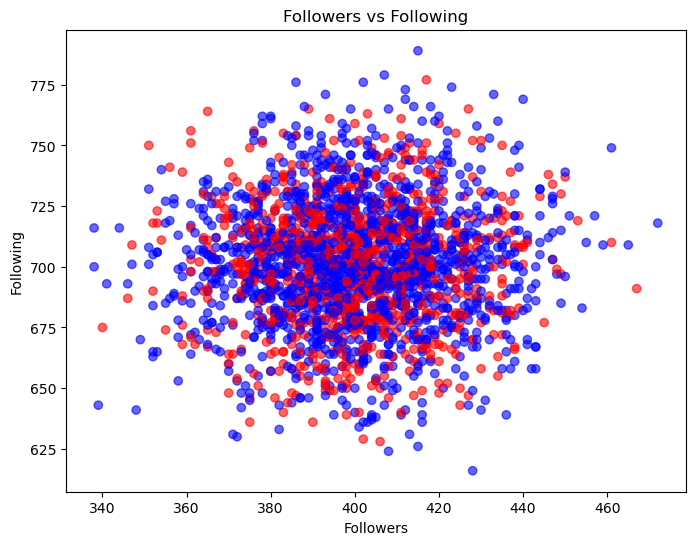

In [12]:
colors = df['is_fake'].map({0:'blue',1:'red'})

plt.figure(figsize=(8,6))

plt.scatter(df['followers'],
            df['following'],
            c=colors,
            alpha=0.6)

plt.title("Followers vs Following")
plt.xlabel("Followers")
plt.ylabel("Following")

plt.show()

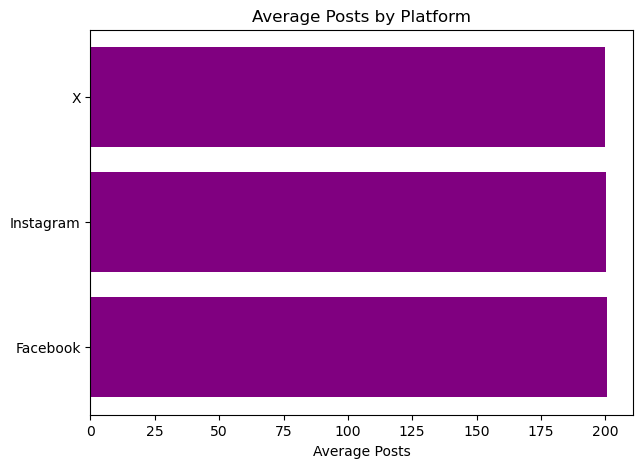

In [13]:
avg_posts = df.groupby('platform')['posts'].mean()

plt.figure(figsize=(7,5))

plt.barh(avg_posts.index,
         avg_posts.values,
         color='purple')

plt.title("Average Posts by Platform")
plt.xlabel("Average Posts")

plt.show()

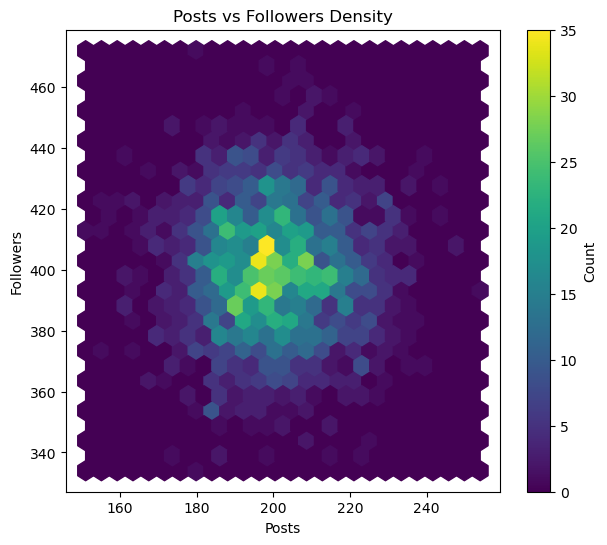

In [14]:
plt.figure(figsize=(7,6))

plt.hexbin(df['posts'],
           df['followers'],
           gridsize=25,
           cmap='viridis')

plt.colorbar(label="Count")

plt.title("Posts vs Followers Density")
plt.xlabel("Posts")
plt.ylabel("Followers")

plt.show()

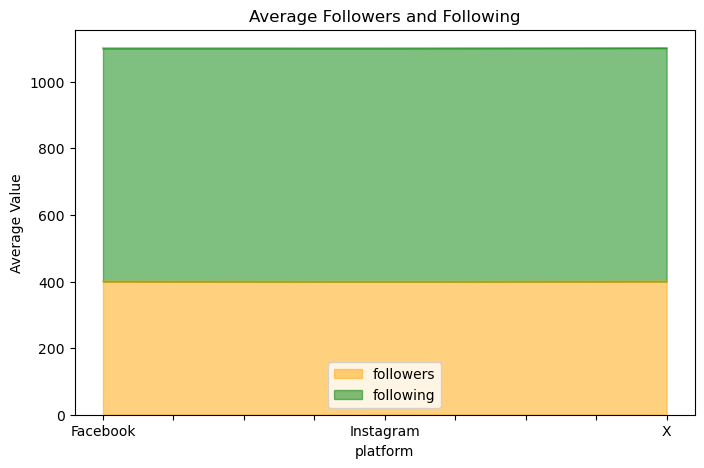

In [15]:
area = df.groupby('platform')[['followers','following']].mean()

area.plot(kind='area',
          figsize=(8,5),
          alpha=0.5,
          color=['orange','green'])

plt.title("Average Followers and Following")
plt.ylabel("Average Value")

plt.show()

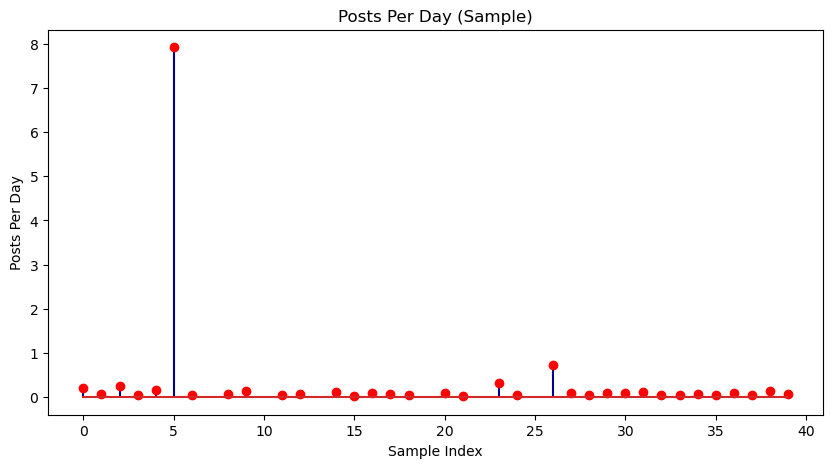

In [16]:
sample = df.head(40)

plt.figure(figsize=(10,5))

markerline, stemlines, baseline = plt.stem(
    sample.index,
    sample['posts_per_day']
)

plt.setp(markerline,color='red')
plt.setp(stemlines,color='darkblue')

plt.title("Posts Per Day (Sample)")
plt.xlabel("Sample Index")
plt.ylabel("Posts Per Day")

plt.show()

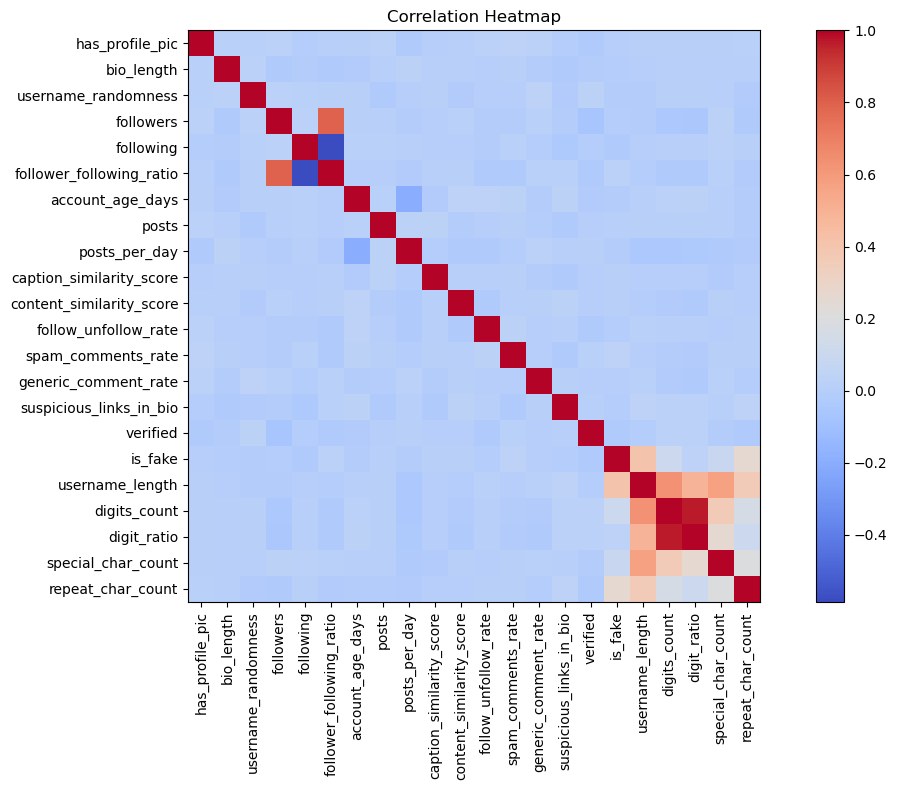

In [17]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(12,8))

plt.imshow(corr,
           cmap='coolwarm',
           interpolation='nearest')

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# Data Pre-processing

In [18]:
# Check and handle missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Categorical column
df['platform'] = df['platform'].fillna(df['platform'].mode()[0])

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('is_fake')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


Missing Values:
platform                    333
has_profile_pic             345
bio_length                  329
username_randomness         337
followers                   338
following                   333
follower_following_ratio    356
account_age_days            343
posts                       317
posts_per_day               311
caption_similarity_score    330
content_similarity_score    328
follow_unfollow_rate        308
spam_comments_rate          338
generic_comment_rate        367
suspicious_links_in_bio     360
verified                    337
is_fake                       0
username                      0
username_length               0
digits_count                  0
digit_ratio                   0
special_char_count            0
repeat_char_count             0
dtype: int64


In [19]:
# Check duplicate records
duplicates = df.duplicated().sum()
print("\nDuplicate Records:", duplicates)


Duplicate Records: 0


In [20]:
# Encode categorical variable
label_encoder = LabelEncoder()
df['platform'] = label_encoder.fit_transform(df['platform'])

print("\nEncoded Platform Values:")
print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))


Encoded Platform Values:
{'Facebook': np.int64(0), 'Instagram': np.int64(1), 'X': np.int64(2)}


In [21]:
# Feature Engineering
# Create interaction feature: Followers-to-Posts Ratio
df['followers_per_post'] = df['followers'] / (df['posts'] + 1)

# Create interaction feature: Bio Length per Username Length
df['bio_per_username_length'] = df['bio_length'] / (df['username_length'] + 1)

# Create interaction feature: Followers per Account Age
df['followers_per_day'] = df['followers'] / (df['account_age_days'] + 1)

print("\nNew Engineered Features Added:")
print([
    'followers_per_post',
    'bio_per_username_length',
    'followers_per_day'
])


New Engineered Features Added:
['followers_per_post', 'bio_per_username_length', 'followers_per_day']


In [22]:
# Feature Selection
X = df.drop(columns=['is_fake', 'username'])
y = df['is_fake']

print("\nSelected Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print(y.name)

# Check class distribution 
print("\nClass Distribution")
print(y.value_counts())


Selected Features:
['platform', 'has_profile_pic', 'bio_length', 'username_randomness', 'followers', 'following', 'follower_following_ratio', 'account_age_days', 'posts', 'posts_per_day', 'caption_similarity_score', 'content_similarity_score', 'follow_unfollow_rate', 'spam_comments_rate', 'generic_comment_rate', 'suspicious_links_in_bio', 'verified', 'username_length', 'digits_count', 'digit_ratio', 'special_char_count', 'repeat_char_count', 'followers_per_post', 'bio_per_username_length', 'followers_per_day']

Target Variable:
is_fake

Class Distribution
is_fake
0    1941
1    1059
Name: count, dtype: int64


In [23]:
# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Shape: (2400, 25)
Testing Shape: (600, 25)

Training Class Distribution:
is_fake
0    1553
1     847
Name: count, dtype: int64

Testing Class Distribution:
is_fake
0    388
1    212
Name: count, dtype: int64


In [24]:
# Feature Scaling 
scaler = StandardScaler() 

X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

# Random Forest Model

In [25]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Create Random Forest model
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# Grid Search with 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Train model
grid_search.fit(X_train, y_train)

# Best Model
best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [26]:
# Predictions
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [27]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy: {:.2f}%".format(accuracy * 100))

Random Forest Accuracy: 92.50%


In [28]:
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Classification Report

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       388
           1       0.90      0.88      0.89       212

    accuracy                           0.93       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.93      0.92       600



In [29]:
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score: {:.4f}".format(auc))

ROC-AUC Score: 0.9845


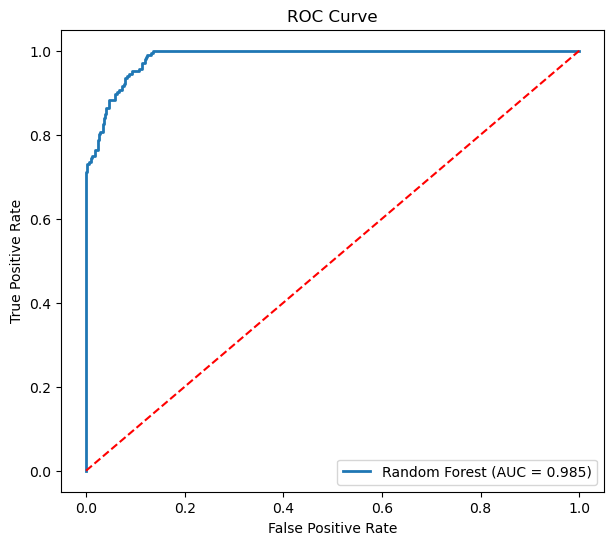

In [30]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label="Random Forest (AUC = {:.3f})".format(auc)
)

plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

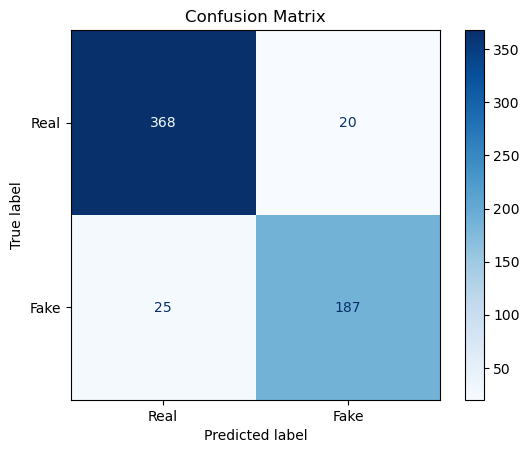

In [31]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real","Fake"]
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [32]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

                     Feature  Importance
17           username_length    0.243322
19               digit_ratio    0.224567
18              digits_count    0.205203
20        special_char_count    0.082069
23   bio_per_username_length    0.042528
21         repeat_char_count    0.029423
2                 bio_length    0.013870
6   follower_following_ratio    0.013733
11  content_similarity_score    0.013077
13        spam_comments_rate    0.013023
24         followers_per_day    0.012142
5                  following    0.012075
10  caption_similarity_score    0.011930
9              posts_per_day    0.011841
12      follow_unfollow_rate    0.011355
7           account_age_days    0.011131
22        followers_per_post    0.011014
4                  followers    0.011006
14      generic_comment_rate    0.009668
8                      posts    0.009497
0                   platform    0.003117
15   suspicious_links_in_bio    0.001466
16                  verified    0.001318
1            has

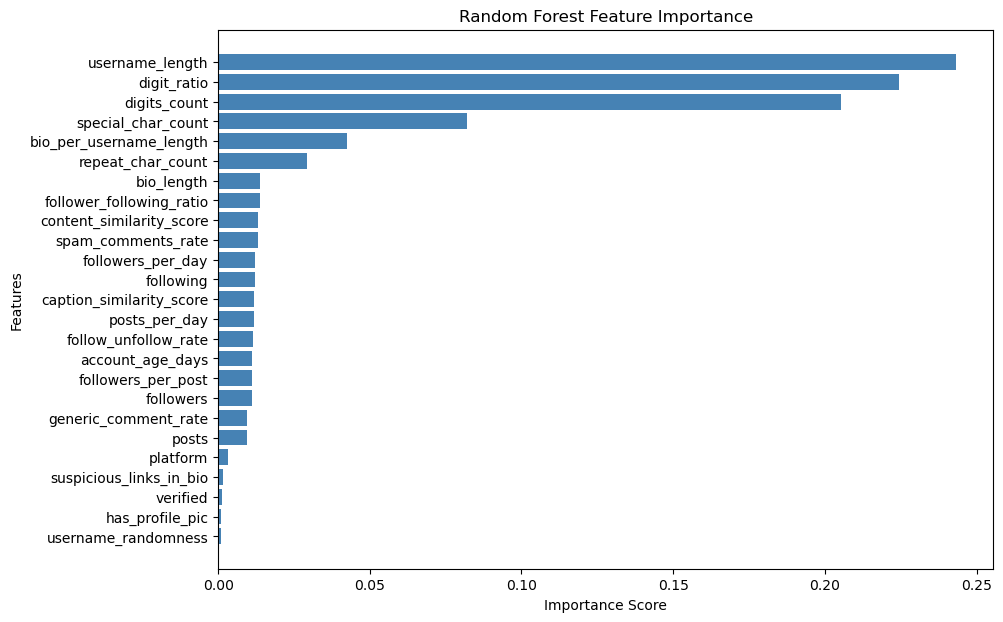

In [33]:
plt.figure(figsize=(10,7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color="steelblue"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()